# Fase 1: Exploración y Análisis de Datos (EDA)
En este primer cuaderno nos enfocaremos en cargar la base de datos oncológica, explorar sus características generales, analizar la colinealidad entre las variables mediante mapas de calor y realizar un análisis avanzado de valores atípicos (outliers) utilizando `Isolation Forest`.

# 1. Librerías y dependencias

In [ ]:
# !pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Descarga del Dataset
Se realiza la importación directa desde el repositorio UCI Machine Learning utilizando su identificador oficial (ID: 17).

In [ ]:
# Cargar el dataset oficial
breast_cancer = fetch_ucirepo(id=17)

# Separar características (X) y variable objetivo (y)
X_raw = breast_cancer.data.features
y_raw = breast_cancer.data.targets

print("Shape inicial de X (características):", X_raw.shape)
print("Shape inicial de y (objetivo):", y_raw.shape)

Shape inicial de X (características): (569, 30)
Shape inicial de y (objetivo): (569, 1)


# 3. Limpieza y Adecuación de Datos
De acuerdo con las especificaciones del dataset, no existen valores faltantes (nulos). Sin embargo, se realizan las siguientes adecuaciones críticas para garantizar el correcto desempeño de los modelos:
1. **Eliminar la columna ID:** El número de identificación del paciente no aporta información predictiva y puede alterar negativamente modelos basados en distancias como k-NN. (Nota: Al usar `fetch_ucirepo`, la columna ID ya se excluye automáticamente de las características, por lo que confirmamos que `X` contiene únicamente las 30 variables continuas).
2. **Codificar la variable objetivo (Diagnosis):** Se transforman las etiquetas categóricas 'M' (Maligno) y 'B' (Benigno) en valores numéricos binarios `1` y `0` respectivamente, lo cual es indispensable para el cálculo de métricas y funciones de pérdida.

In [ ]:
# Copiar las características y verificar que no tengan IDs numéricos irrelevantes
X = X_raw.copy()

# Codificar la variable objetivo (Diagnosis): M -> 1, B -> 0
y = y_raw.copy()
y['Diagnosis'] = y['Diagnosis'].map({'M': 1, 'B': 0})

# Consolidar en un único DataFrame para la fase de Análisis Exploratorio (EDA)
df = pd.concat([X, y], axis=1)

# Verificar la ausencia de valores faltantes en todo el DataFrame
print(f"Valores faltantes totales en el dataset: {df.isnull().sum().sum()}")

Valores faltantes totales en el dataset: 0


In [ ]:
# Guardar el dataset original en la carpeta 'data'
df.to_csv('./data/dataset_cancer.csv', index=False)

# 4. Análisis exploratorio de datos (EDA)
Evaluación de la composición de la base de datos, comportamiento de las variables numéricas y su relación con la clasificación del tumor.

## 4.1. Análisis univariado y bivariado (Distribución y separación de clases)
Dado que todas las variables predictoras son continuas y el objetivo es la clasificación, se integran las perspectivas univariada y bivariada.

### 4.1.1. Variable objetivo
Análisis del balance de las clases dentro del conjunto de datos para la variable `Diagnosis`, representado mediante su distribución absoluta y su proporción porcentual.

Benigno (0): 357 muestras (62.74%)
Maligno (1): 212 muestras (37.26%)


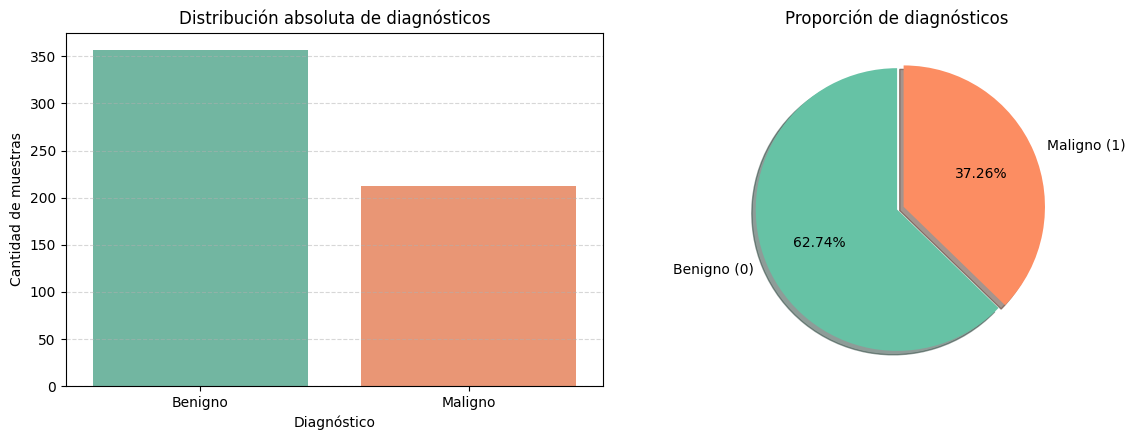

In [ ]:
conteo = df['Diagnosis'].value_counts()
print(f"Benigno (0): {conteo[0]} muestras ({conteo[0] / len(df) * 100:.2f}%)")
print(f"Maligno (1): {conteo[1]} muestras ({conteo[1] / len(df) * 100:.2f}%)")

# Crear una figura con 1 fila y 2 columnas
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4.5))

# 1. Gráfico de barras (Ahora en la posición 0, izquierda)
sns.countplot(x='Diagnosis', data=df, hue='Diagnosis', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Distribución absoluta de diagnósticos')
axes[0].set_xlabel('Diagnóstico')
axes[0].set_ylabel('Cantidad de muestras')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Benigno', 'Maligno'])
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# 2. Gráfico circular / Pie Chart (Ahora en la posición 1, derecha)
axes[1].pie(conteo, labels=['Benigno (0)', 'Maligno (1)'], autopct='%1.2f%%', 
            colors=sns.color_palette('Set2'), startangle=90, explode=(0, 0.05), shadow=True)
axes[1].set_title('Proporción de diagnósticos')

plt.tight_layout()
plt.show()

### 4.1.2. Características clínicas
Para las 10 características físicas base de los núcleos celulares, se evalúan sus tres métricas calculadas (Promedio, Error Estándar y Peor valor). Por cada una se presenta:
* **Histograma:** Para observar la distribución general de los datos.
* **Boxplot (Separado por Diagnóstico):** Para identificar visualmente el poder discriminativo de la variable (separación entre cajas) y la presencia de valores atípicos. 

*Nota Clínica:* Los valores atípicos identificados en los diagramas de caja no serán eliminados, ya que representan variaciones morfológicas reales de tumores severos y borrarlos restaría capacidad predictiva al modelo.

In [ ]:
import matplotlib.patches as mpatches

# Crear una copia temporal de los datos para asignar etiquetas claras
df_plot = df.copy()
df_plot['Etiqueta_Diag'] = df_plot['Diagnosis'].map({0: 'Benigno', 1: 'Maligno'})

# Extraer los colores exactos de la paleta 'Set2' que estamos usando
color_benigno = sns.color_palette('Set2')[0]
color_maligno = sns.color_palette('Set2')[1]

# Iterar sobre las 10 características base
for i in range(10):
    col_mean = X.columns[i]
    col_se = X.columns[i + 10]
    col_worst = X.columns[i + 20]
    
    grupo_columnas = [col_mean, col_se, col_worst]
    
    fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 10))
    
    nombre_base = col_mean.replace('1', '').replace('_mean', '').replace('mean', '').capitalize()
    fig.suptitle(f'Análisis de la característica: {nombre_base}', fontsize=16, fontweight='bold')
    
    for j, col in enumerate(grupo_columnas):
        # 1. Histograma (Izquierda)
        sns.histplot(data=df_plot, x=col, kde=True, ax=axes[j, 0], color='skyblue')
        axes[j, 0].set_title(f'Histograma de {col}')
        axes[j, 0].set_xlabel('')
        axes[j, 0].set_ylabel('Frecuencia')
        
        # 2. Boxplot (Derecha) 
        sns.boxplot(data=df_plot, x=col, y='Etiqueta_Diag', ax=axes[j, 1], 
                    hue='Etiqueta_Diag', palette='Set2', order=['Benigno', 'Maligno'])
        
        axes[j, 1].set_title(f'Boxplot de {col}')
        axes[j, 1].set_xlabel('')
        axes[j, 1].set_ylabel('') 
        axes[j, 1].set_yticks([]) # Ocultar los textos del eje Y
        
        # ==========================================
        # CREACIÓN MANUAL E INFALIBLE DE LA LEYENDA
        # ==========================================
        patch_benigno = mpatches.Patch(color=color_benigno, label='Benigno')
        patch_maligno = mpatches.Patch(color=color_maligno, label='Maligno')
        axes[j, 1].legend(handles=[patch_benigno, patch_maligno], loc='upper right')

    plt.tight_layout()
    fig.subplots_adjust(top=0.92) 
    plt.show()
    
    print("-" * 100)

### Análisis Clínico de las Distribuciones
De las gráficas anteriores extraemos tres conclusiones clave para el modelado:

1. **Poder Predictivo:** Variables de tamaño y forma (como `radius` y `concavity`) separan muy bien ambas clases. Otras, como `smoothness`, se superponen mucho, aportando menor valor discriminativo individual.
2. **Dispersión Maligna:** Los tumores benignos tienen distribuciones estrechas y agrupadas. Los malignos presentan alta varianza y asimetría, lo cual tiene sentido biológico por el crecimiento celular descontrolado.
3. **Valores Atípicos (Outliers):** La clase maligna muestra muchos puntos extremos. Clínicamente representan casos severos y no simples errores de medición. Por ello, **no los eliminaremos en este análisis univariado**; más adelante aplicaremos **Isolation Forest** para tratarlos desde una perspectiva multivariada y más robusta.

## 4.2. Análisis multivariado (Matriz de correlación)
Para evaluar la redundancia de información (colinealidad) entre las 30 características clínicas, se calcula la matriz de correlación lineal de Pearson. Valores cercanos a `1` o `-1` indican que dos variables aportan exactamente la misma información geométrica o estructural del tumor.

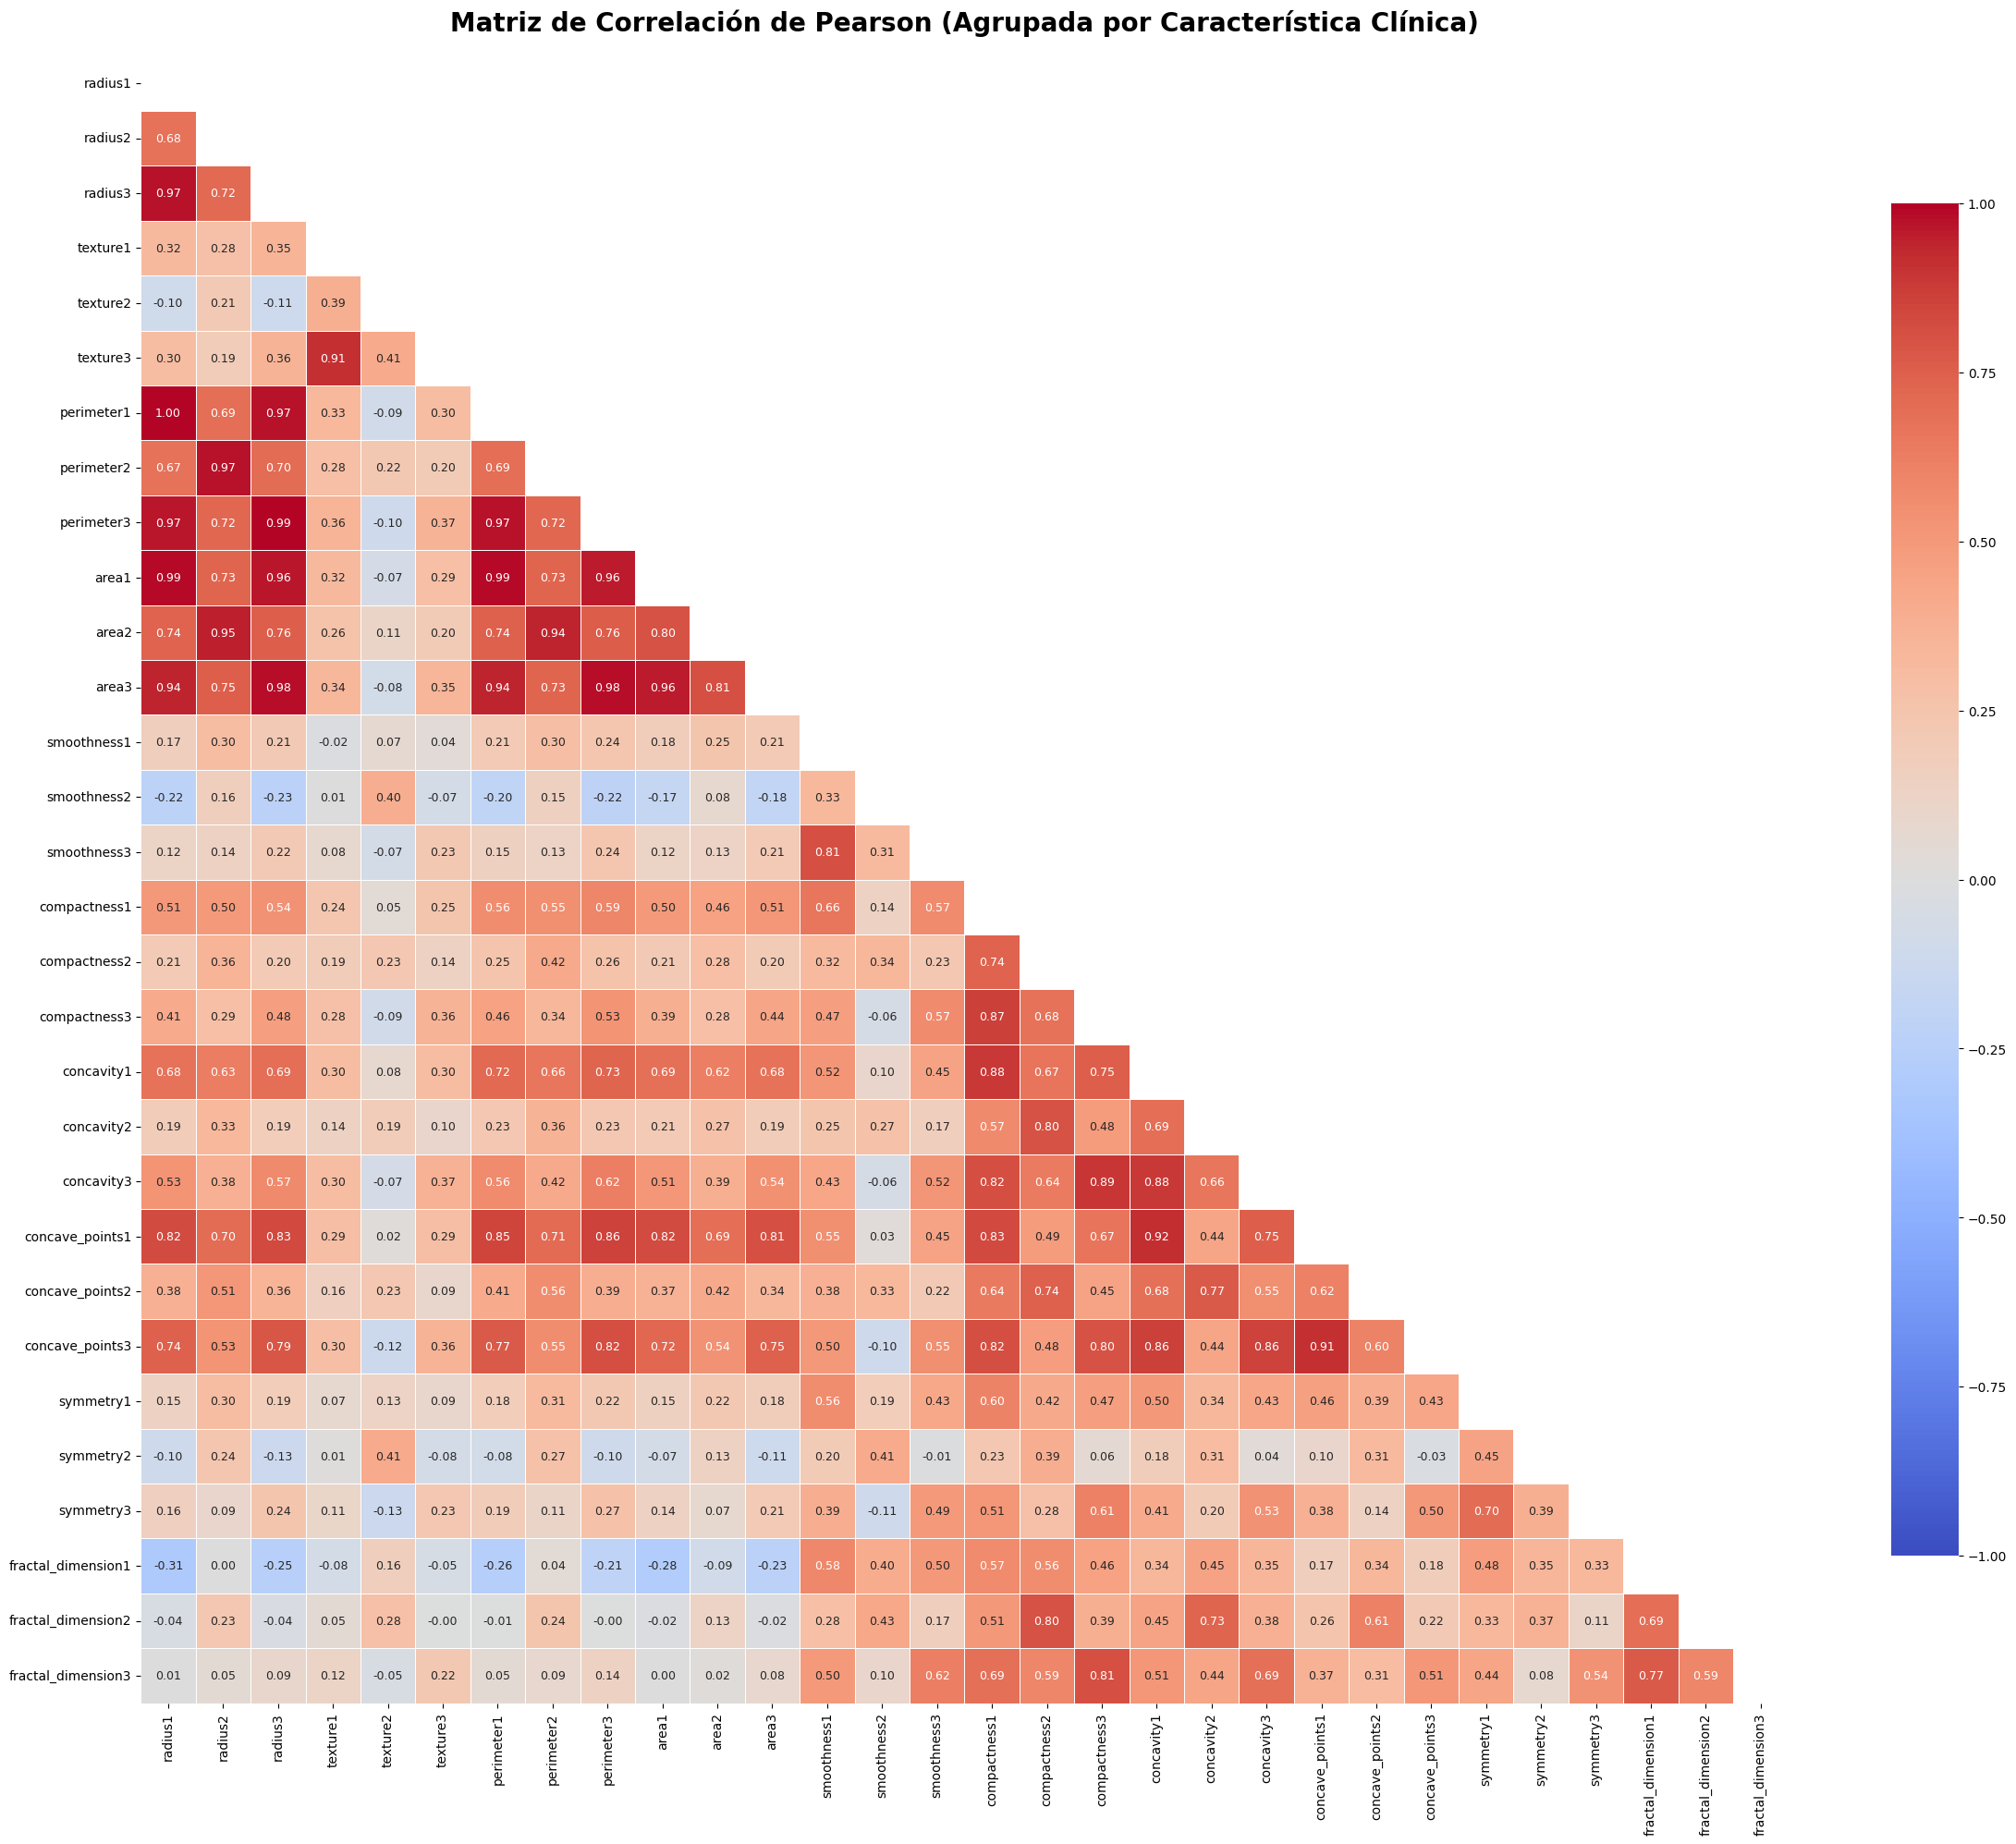

In [ ]:
# 1. Reorganizar lógicamente las columnas (Agrupar las 3 medidas por cada característica base)
columnas_ordenadas = []
for i in range(10):
    columnas_ordenadas.append(X.columns[i])       # Promedio (mean)
    columnas_ordenadas.append(X.columns[i + 10])  # Error estándar (se)
    columnas_ordenadas.append(X.columns[i + 20])  # Peor caso (worst)

# 2. Calcular la matriz de correlación usando el DataFrame reordenado
matriz_corr = X[columnas_ordenadas].corr()

# 3. Crear una máscara para ocultar el triángulo superior (para una visualización más limpia)
mascara = np.triu(np.ones_like(matriz_corr, dtype=bool))

# 4. Configurar el tamaño de la figura
plt.figure(figsize=(24, 20))
plt.title('Matriz de Correlación de Pearson (Agrupada por Característica Clínica)', fontsize=20, fontweight='bold', pad=20)

# 5. Dibujar el mapa de calor (heatmap)
sns.heatmap(matriz_corr, mask=mascara, annot=True, fmt=".2f", cmap='coolwarm',
            vmin=-1, vmax=1, square=True, linewidths=.5, cbar_kws={"shrink": .8},
            annot_kws={"size": 9})

plt.tight_layout()
plt.show()

## 4.3. Capacidad predictiva (Correlación con la variable objetivo)
Para tomar decisiones informadas sobre qué variables eliminar en casos de alta multicolinealidad, se calcula la correlación individual de cada característica frente al diagnóstico (`Diagnosis`). Las variables con mayor correlación (positiva o negativa) son las que aportan más información pura al modelo para separar las clases.

C:\Users\aleja\AppData\Local\Temp\ipykernel_13424\3030600544.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_objetivo.values, y=corr_objetivo.index, palette='coolwarm')


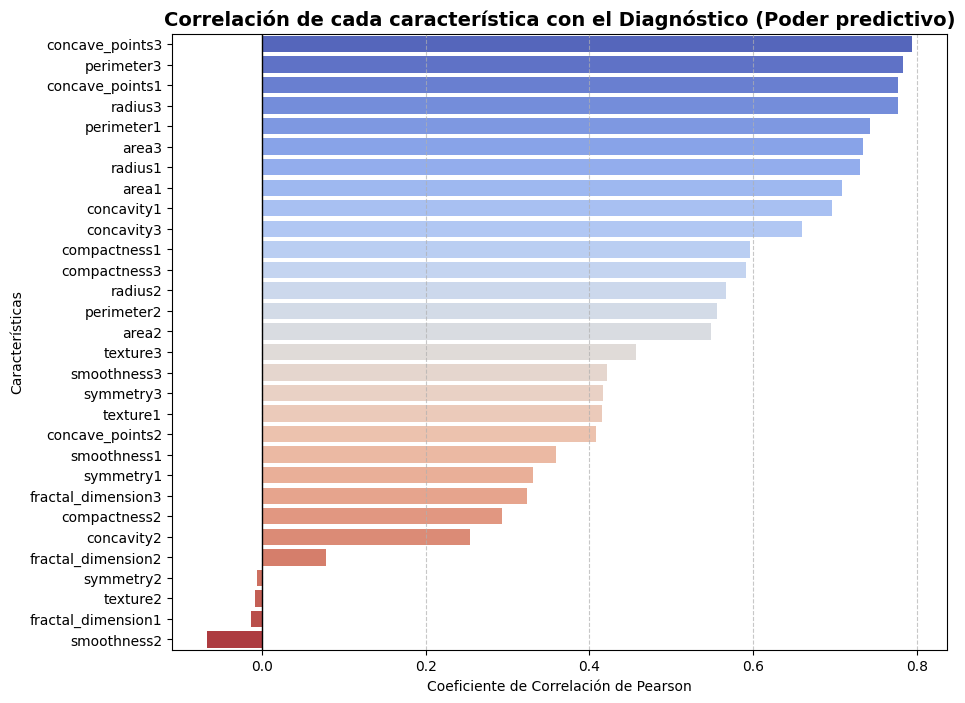

In [ ]:
# Calcular correlación con 'Diagnosis' y ordenar de mayor a menor (omitiendo la correlación de Diagnosis consigo misma)
corr_objetivo = df.corr()['Diagnosis'].drop('Diagnosis').sort_values(ascending=False)

# Crear un gráfico de barras horizontal para visualizar el poder predictivo
plt.figure(figsize=(10, 8))
sns.barplot(x=corr_objetivo.values, y=corr_objetivo.index, palette='coolwarm')
plt.title('Correlación de cada característica con el Diagnóstico (Poder predictivo)', fontsize=14, fontweight='bold')
plt.xlabel('Coeficiente de Correlación de Pearson')
plt.ylabel('Características')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.axvline(x=0, color='black', linewidth=1)
plt.show()

## 5. Análisis de Valores Atípicos Multivariados (Isolation Forest)
Hasta este punto hemos analizado las variables una por una (Boxplots) y en pares (Correlaciones). Como paso final de la exploración de datos, evaluaremos matemáticamente la presencia de anomalías multidimensionales utilizando `Isolation Forest`.

Este algoritmo nos permitirá saber si existen tumores que, al combinar todas sus 30 características al mismo tiempo, resultan ser estadísticamente extremos respecto a la población general.

In [ ]:
# 1. Inicializar el Isolation Forest (Buscando ~5% de valores extremos)
from sklearn.ensemble import IsolationForest
iso_forest = IsolationForest(contamination=0.05, random_state=30)

# 2. Predecir atípicos sobre la matriz X original
predicciones_atipicos = iso_forest.fit_predict(X)

# 3. Filtrar resultados (-1: Atípico, 1: Normal)
mascara_atipicos = predicciones_atipicos == -1
tumores_atipicos = X[mascara_atipicos]
tumores_normales = X[~mascara_atipicos]

print(f"Total de tumores analizados: {len(X)}")
print(f"Tumores clasificados como 'Normales': {len(tumores_normales)}")
print(f"Tumores clasificados como 'Atípicos' por el algoritmo: {len(tumores_atipicos)}\n")

# 4. Análisis Clínico de una variable de tamaño
columna_analisis = 'area1' if 'area1' in X.columns else X.columns[3]

print(f"--- Análisis de la variable geométrica '{columna_analisis}' ---")
print(f"Tamaño promedio en tumores normales: {tumores_normales[columna_analisis].mean():.2f}")
print(f"Tamaño promedio en tumores ATÍPICOS: {tumores_atipicos[columna_analisis].mean():.2f}\n")

print("Muestra de las características de los tumores atípicos detectados:")
display(tumores_atipicos.head())

Total de tumores analizados: 569
Tumores clasificados como 'Normales': 540
Tumores clasificados como 'Atípicos' por el algoritmo: 29

--- Análisis de la variable geométrica 'area1' ---
Tamaño promedio en tumores normales: 624.81
Tamaño promedio en tumores ATÍPICOS: 1215.02

Muestra de las características de los tumores atípicos detectados:


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.2776,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
3,11.42,20.38,77.58,386.1,0.14250,0.2839,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730
9,12.46,24.04,83.97,475.9,0.11860,0.2396,0.2273,0.08543,0.2030,0.08243,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.2075
12,19.17,24.80,132.40,1123.0,0.09740,0.2458,0.2065,0.11180,0.2397,0.07800,...,20.96,29.94,151.70,1332.0,0.1037,0.3903,0.3639,0.1767,0.3176,0.1023
42,19.07,24.81,128.30,1104.0,0.09081,0.2190,0.2107,0.09961,0.2310,0.06343,...,24.09,33.17,177.40,1651.0,0.1247,0.7444,0.7242,0.2493,0.4670,0.1038


### Conclusión General de la Fase de Exploración

1. **Sobre las Correlaciones:** Se detectó alta colinealidad geométrica y características con bajo poder predictivo. En la siguiente fase del proyecto, no utilizaremos la base de datos cruda; aplicaremos técnicas de Filtrado Manual (umbrales de 0.85 y 0.05), selección algorítmica (LASSO) y reducción de dimensionalidad (PCA) para resolver esto.
2. **Sobre los Valores Atípicos:** Los 29 tumores marcados como "anomalías" por el *Isolation Forest* presentan magnitudes geométricas gigantes (el doble de área). En oncología, esto no es un error de medición, sino cáncer en etapas severas. **Se conservará toda la información biológica** para no cegar a los modelos predictivos frente a los casos más graves.

Con los datos explorados, auditados y comprendidos, procedemos al *Notebook 02* para aplicar las transformaciones y reducciones del espacio de características.